
Initial Dataset Sample:
   Student_ID  Gender  Math_Score  Science_Score  English_Score  \
0           1  Female   99.947842      69.175418      92.636253   
1           2  Female   53.219927      46.296027      68.491874   
2           3    Male  102.704925      53.059508      73.573145   
3           4  Female   72.857003      96.453830      65.658953   
4           5    Male   88.925288      60.909363      75.265665   

   Attendance_Percentage  Study_Hours_per_Week  
0              85.444920             21.533846  
1              98.836680             11.863209  
2              75.488065             20.445453  
3              89.786475              7.944093  
4              91.420528             15.106988  

Missing Values Before Treatment:
Student_ID               0
Gender                   0
Math_Score               1
Science_Score            1
English_Score            0
Attendance_Percentage    1
Study_Hours_per_Week     0
dtype: int64

Missing Values After Treatment:
Student_I

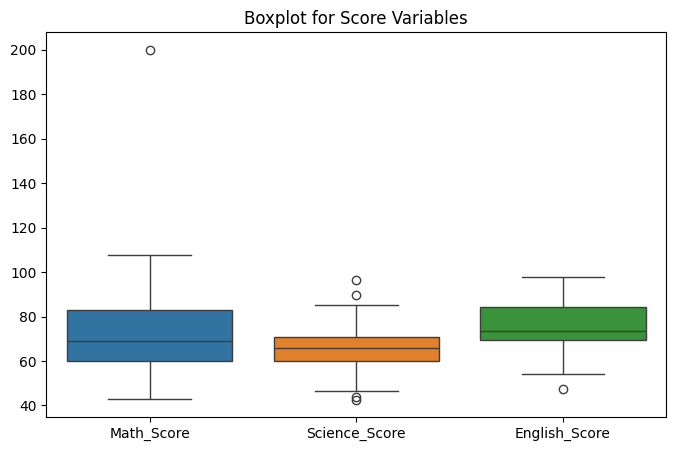


Outlier Bounds for Math_Score:
Lower Bound: 25.515429552692744
Upper Bound: 117.62429215267197

Skewness Before Transformation: 0.4267636287578622
Skewness After Transformation: -0.5289317050813682


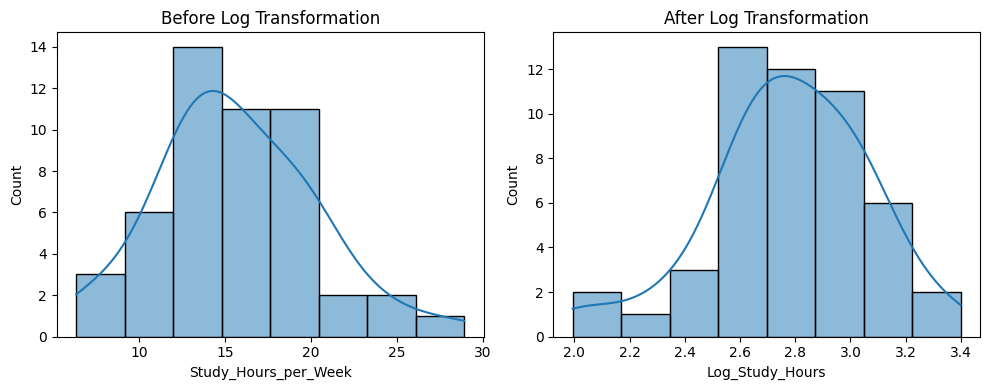


Final Cleaned Dataset Sample:
   Student_ID  Gender  Math_Score  Science_Score  English_Score  \
0           1  Female   99.947842      69.175418      92.636253   
1           2  Female   53.219927      46.296027      68.491874   
2           3    Male  102.704925      53.059508      73.573145   
3           4  Female   72.857003      96.453830      65.658953   
4           5    Male   88.925288      60.909363      75.265665   

   Attendance_Percentage  Study_Hours_per_Week  Log_Study_Hours  
0              85.444920             21.533846         3.115018  
1              98.836680             11.863209         2.554371  
2              75.488065             20.445453         3.065513  
3              89.786475              7.944093         2.190993  
4              91.420528             15.106988         2.779253  

Practical Completed Successfully.


In [1]:
# ===============================================
# DSBDAL Practical No. 2
# Data Wrangling II - Academic Performance Dataset
# ===============================================
# Step 1: Import Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
# -----------------------------------------------
# Step 2: Create Academic Performance Dataset
# -----------------------------------------------
# Setting seed for reproducibility
np.random.seed(10)
data = {
'Student_ID': range(1, 51),
'Gender': np.random.choice(['Male', 'Female'], 50),
'Math_Score': np.random.normal(70, 15, 50),
'Science_Score': np.random.normal(65, 12, 50),
'English_Score': np.random.normal(75, 10, 50),
'Attendance_Percentage': np.random.normal(85, 8, 50),
'Study_Hours_per_Week': np.random.normal(15, 5, 50)
}
df = pd.DataFrame(data)
# -----------------------------------------------
# Introduce Missing Values & Inconsistencies
# -----------------------------------------------
df.loc[5, 'Math_Score'] = np.nan
df.loc[10, 'Science_Score'] = np.nan
df.loc[15, 'Attendance_Percentage'] = np.nan# Inconsistency in Gender
df.loc[20, 'Gender'] = 'male'# Introduce Outlier
df.loc[25, 'Math_Score'] = 200
print("\nInitial Dataset Sample:")
print(df.head())# -----------------------------------------------
# Step 3: Handling Missing Values
# -----------------------------------------------
print("\nMissing Values Before Treatment:")
print(df.isnull().sum())# Mean Imputation
df['Math_Score'] = df['Math_Score'].fillna(df['Math_Score'].mean())
df['Science_Score'] = df['Science_Score'].fillna(df['Science_Score'].mean())
df['Attendance_Percentage'] = df['Attendance_Percentage'].fillna(df['Attendance_Percentage'].mean())

print("\nMissing Values After Treatment:")
print(df.isnull().sum())# -----------------------------------------------
# Handling Inconsistencies
# -----------------------------------------------
print("\nUnique Gender Values Before Cleaning:")
print(df['Gender'].unique())
df['Gender'] = df['Gender'].str.capitalize()
print("\nUnique Gender Values After Cleaning:")
print(df['Gender'].unique())# -----------------------------------------------
# Step 4: Detect and Treat Outliers
# -----------------------------------------------
# Boxplot Visualization
plt.figure(figsize=(8,5))
sns.boxplot(data=df[['Math_Score', 'Science_Score', 'English_Score']])
plt.title("Boxplot for Score Variables")
plt.show()# IQR Method for Math_Score
Q1 = df['Math_Score'].quantile(0.25)
Q3 = df['Math_Score'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print("\nOutlier Bounds for Math_Score:")
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)# Capping (Winsorization)
df['Math_Score'] = np.where(df['Math_Score'] > upper_bound,
upper_bound, df['Math_Score'])
df['Math_Score'] = np.where(df['Math_Score'] < lower_bound,
lower_bound, df['Math_Score'])# -----------------------------------------------
# Step 5: Data Transformation
# -----------------------------------------------
print("\nSkewness Before Transformation:",
df['Study_Hours_per_Week'].skew())# Log Transformation
df['Log_Study_Hours'] = np.log(df['Study_Hours_per_Week'] + 1)
print("Skewness After Transformation:",
df['Log_Study_Hours'].skew())# Visual Comparison
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.histplot(df['Study_Hours_per_Week'], kde=True)
plt.title("Before Log Transformation")
plt.subplot(1,2,2)
sns.histplot(df['Log_Study_Hours'], kde=True)
plt.title("After Log Transformation")
plt.tight_layout()
plt.show()# -----------------------------------------------
# Final Cleaned Dataset
# -----------------------------------------------
print("\nFinal Cleaned Dataset Sample:")
print(df.head())
print("\nPractical Completed Successfully.")